# Regressão Linear com PyTorch

## Objetivos

Este exemplo utiliza regressão linear para estimar o comprimento das sépalas da íris a partir do seu comprimento das pétalas.
Utiliza-se:
- a função de perda MSE do PyTorch,
- treinamento dos parâmetros via gradiente descendente usando o otimizador.
- A rede é criada com uma camada nn.Linear()

## Importação dos pacotes

In [1]:
%matplotlib inline
import torch
from torch import nn, optim
from torch.autograd import Variable
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

torch.manual_seed(1234)

## Leitura dos dados

In [2]:
iris = load_iris()
data = iris.data[iris.target==1,::2]  # comprimento das sépalas e pétalas, indices 0 e 2

x_train = data[:,0:1].astype(np.float32)
y_train = data[:,1:2].astype(np.float32)

n_samples = x_train.shape[0]
print('x_train.shape:',x_train.shape, x_train.dtype)
print('y_train.shape:',y_train.shape, y_train.dtype)

print('x_train[:5]:\n', x_train[:5])
print('y_train[:5]:\n', y_train[:5])

x_train.shape: (50, 1) float32
y_train.shape: (50, 1) float32
x_train[:5]:
 [[7. ]
 [6.4]
 [6.9]
 [5.5]
 [6.5]]
y_train[:5]:
 [[4.7]
 [4.5]
 [4.9]
 [4. ]
 [4.6]]


### Normalização dos dados

In [3]:
x_train -= x_train.min()
x_train /= x_train.max()
y_train -= y_train.min()
y_train /= y_train.max()


In [4]:
x_train_bias = np.hstack([np.ones(shape=(n_samples,1)), x_train])

In [5]:
x_train_bias = torch.FloatTensor(x_train_bias)
y_train      = torch.FloatTensor(y_train)

## Criação do modelo da rede

In [6]:
model = torch.nn.Linear(2, 1, bias=False)

### Verificando a inicialização dos parâmetros

In [7]:
model.weight.data = torch.zeros(1,2)
torch.nn.init.uniform(model.weight.data, -0.1, 0.1)
model.weight.data

/tmp/ipykernel_56978/1486225639.py:2: FutureWarning: `nn.init.uniform` is now deprecated in favor of `nn.init.uniform_`.
  torch.nn.init.uniform(model.weight.data, -0.1, 0.1)


tensor([[-0.0480, -0.0267]])

### Testando o predict da rede

In [8]:
model(Variable(torch.ones((5,2))))

tensor([[-0.0747],
        [-0.0747],
        [-0.0747],
        [-0.0747],
        [-0.0747]], grad_fn=<MmBackward0>)

## Treinamento

### Definindo função de perda e otimizador

In [9]:
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.3)

### Laço de treinamento

In [10]:
num_epochs = 120
w0_list = []
w1_list = []
for epoch in range(num_epochs):
    inputs = x_train_bias
    target = y_train

    # forward - predict
    out = model(inputs)

    w0_list.append(model.weight.data[0][0].item())
    w1_list.append(model.weight.data[0][1].item())

    #loss cálculo da função de perda
    loss = criterion(out, target)

    # backward e otimizador
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # verbose
    if (epoch+1) % 20 == 0:
        print('Epoch[{}/{}], loss: {:.6f}'
              .format(epoch+1, num_epochs, loss.data))

Epoch[20/120], loss: 0.024990
Epoch[40/120], loss: 0.022381
Epoch[60/120], loss: 0.021554
Epoch[80/120], loss: 0.021291
Epoch[100/120], loss: 0.021208
Epoch[120/120], loss: 0.021182


## Avaliação

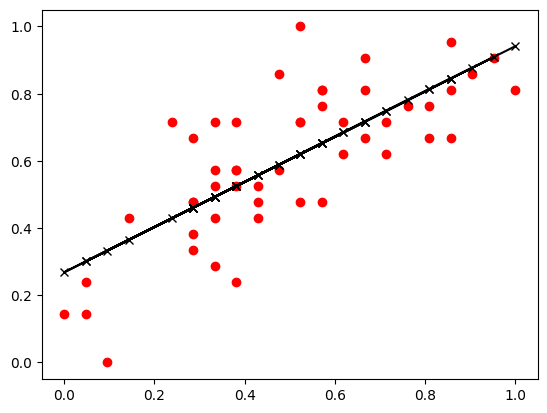

In [11]:
y_pred = model(x_train_bias)
plt.plot(x_train, y_train.numpy(), 'ro', label='Original data')
plt.plot(x_train, y_pred.data.numpy(), 'kx-', label='Fitting Line')
plt.show()

# Exercícios

- 1) Calcule o valor da função de custo (MSE) depois da rede treinada, utilizando a
   função `criterion` utilizada no laço de treinamento.

In [12]:
#todo

<details>
<summary>Mostrar Resultado</summary>

```python
y_pred = model(Variable(x_train_bias))
loss = criterion(y_pred, Variable(y_train))
print(loss)
```

</details>

- 2) Faça igual o exercício do notebook anterior, de plotar um gráfico scatterplot para
   mostrar a evolução dos parâmetros durante o treinamento pelo gradiente descendente.

In [13]:
# todo

<details>
<summary>Mostrar Resultado</summary>

```python
plt.scatter(w0_list,w1_list)
w0_old = None
for (w0,w1) in zip(w0_list,w1_list):
    if w0_old:
        plt.arrow(w0_old, w1_old, w0-w0_old, w1-w1_old,
                  head_length=0.01,head_width=0.01,shape='full',
                  length_includes_head=True)
    w0_old,w1_old = w0,w1
```

</details>

# Aprendizados

---
## Exercícios — Resolvidos

**Nome:** Thiago Pereira Magalhães | **Email:** tpm3@cesar.school

### Exercício 1 — MSE Final com `criterion`


In [14]:
# Exercício 1: Calcular MSE com criterion após treinamento
from torch.autograd import Variable
y_pred_final = model(Variable(x_train_bias))
loss_final = criterion(y_pred_final, Variable(y_train))
print(f'MSE final (criterion): {loss_final.item():.6f}')


MSE final (criterion): 0.021181


### Exercício 2 — Evolução dos Pesos (Scatter Plot)


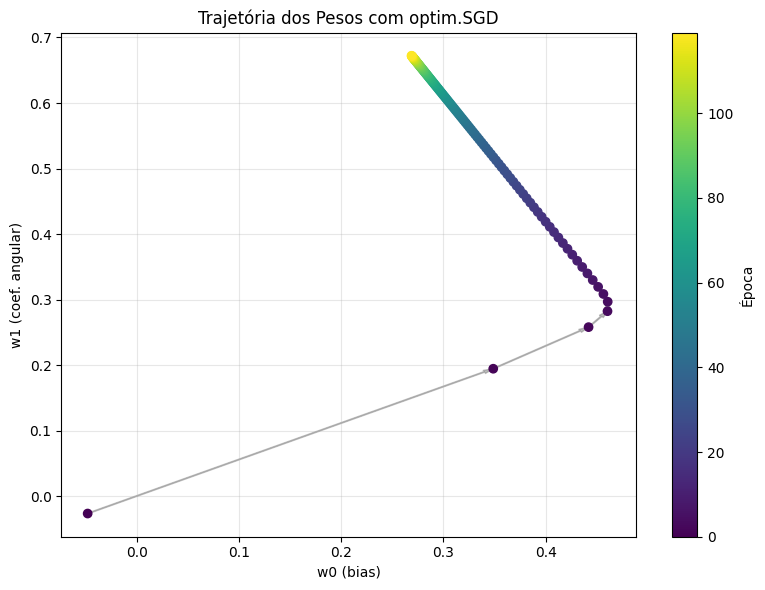

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sc = plt.scatter(w0_list, w1_list, c=range(len(w0_list)), cmap='viridis', zorder=5)
plt.colorbar(sc, label='Época')

w0_old = None
for (w0, w1) in zip(w0_list, w1_list):
    if w0_old is not None:
        plt.arrow(w0_old, w1_old, w0-w0_old, w1-w1_old,
                  head_length=0.01, head_width=0.005, shape='full',
                  length_includes_head=True, color='gray', alpha=0.5)
    w0_old, w1_old = w0, w1

plt.xlabel('w0 (bias)')
plt.ylabel('w1 (coef. angular)')
plt.title('Trajetória dos Pesos com optim.SGD')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Demonstração — O que acontece sem `optimizer.zero_grad()`?

No PyTorch, os gradientes são **acumulados** (somados) a cada chamada de `backward()`. Sem `zero_grad()`, o gradiente de cada passo é somado aos anteriores, causando um crescimento exponencial que distorce a atualização dos pesos — equivalente a usar um `learning_rate` efetivo que cresce a cada época.


=== COM zero_grad() ===
Loss final: 0.021193

=== SEM zero_grad() ===
Loss final: 0.047526


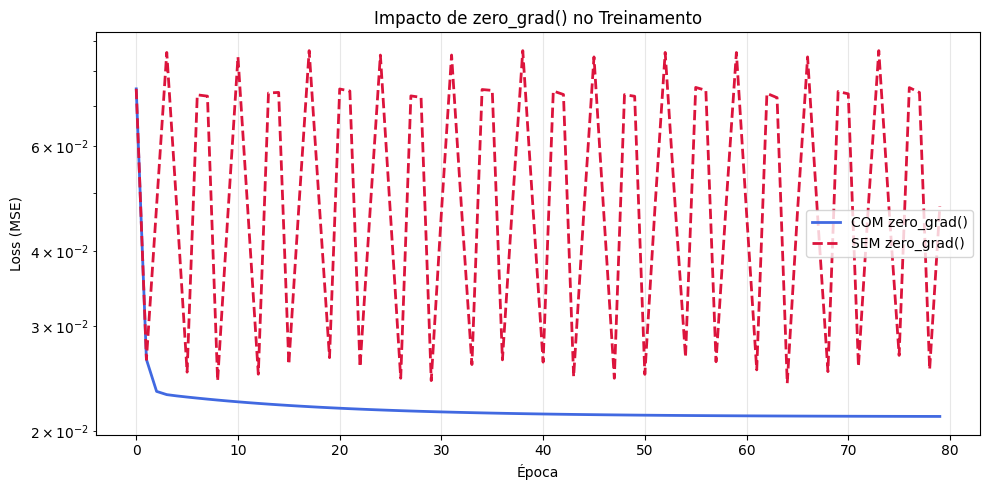

In [16]:
import torch
from torch import nn, optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

# Recarregar dados
torch.manual_seed(1234)
iris_d = load_iris()
data_d = iris_d.data[iris_d.target==1,::2]
x_d = data_d[:,0:1].astype(np.float32)
y_d = data_d[:,1:2].astype(np.float32)
x_d -= x_d.min(); x_d /= x_d.max()
y_d -= y_d.min(); y_d /= y_d.max()
n_d = x_d.shape[0]
xb_d = np.hstack([np.ones((n_d,1)), x_d])
xb_t = torch.FloatTensor(xb_d)
y_t  = torch.FloatTensor(y_d)

crit = nn.MSELoss()

def run_training(zero_grad_enabled, n_epochs=80):
    torch.manual_seed(42)
    m = nn.Linear(2, 1, bias=False)
    opt = optim.SGD(m.parameters(), lr=0.3)
    losses = []
    for e in range(n_epochs):
        out = m(xb_t)
        loss = crit(out, y_t)
        if zero_grad_enabled:
            opt.zero_grad()  # <-- limpa gradientes acumulados
        loss.backward()
        opt.step()
        val = loss.item() if not torch.isnan(loss) else float('nan')
        losses.append(val)
        if torch.isnan(loss) or val > 1e6:
            print(f'  [Época {e+1}] DIVERGÊNCIA DETECTADA!')
            break
    return losses

print('=== COM zero_grad() ===')
losses_with = run_training(zero_grad_enabled=True)
print(f'Loss final: {losses_with[-1]:.6f}')

print('\n=== SEM zero_grad() ===')
losses_without = run_training(zero_grad_enabled=False)
print(f'Loss final: {losses_without[-1]:.6f}')

# Plot
plt.figure(figsize=(10, 5))
plt.plot(losses_with, label='COM zero_grad()', color='royalblue', linewidth=2)
plt.plot(losses_without, label='SEM zero_grad()', color='crimson', linewidth=2, linestyle='--')
plt.xlabel('Época')
plt.ylabel('Loss (MSE)')
plt.title('Impacto de zero_grad() no Treinamento')
plt.legend()
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.tight_layout()
plt.show()


## 📚 Aprendizados — `optim.SGD` e `zero_grad()`

### Por que `optimizer.zero_grad()` é essencial?

O PyTorch acumula gradientes por design (útil para RNNs e gradientes acumulados). Em cada chamada de `loss.backward()`, os valores em `param.grad` são **somados** ao que já existia. Sem `zero_grad()` antes de cada backward:

$$g_t^{acum} = g_1 + g_2 + \ldots + g_t$$

O passo do gradiente descendente vira:
$$w_{t+1} = w_t - \eta \cdot g_t^{acum}$$

Isso é equivalente a usar uma taxa de aprendizado crescente ($\eta_{ef} = t \cdot \eta$), causando instabilidade e divergência.

### Papel do `optim.SGD`
O `optim.SGD` encapsula a atualização $w = w - \eta \nabla J_w$ e gerencia os parâmetros de todos os módulos da rede. Ao chamar `optimizer.step()`, ele aplica a atualização a todos os parâmetros registrados, eliminando a necessidade de atualização manual `model.weight.data -= lr * grad`.
